In [ ]:
# ============================================================
# RESUME CELL - run this first every session
# ============================================================
import os, sys, cv2, numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from skimage import img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Paths
BLUR_IMGS = "/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/blur/images"
SHARP_IMGS = "/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images"
DEBLURRED_PATH = "/kaggle/working/deblurred_images"

# File lists
blur_files = sorted(os.listdir(BLUR_IMGS))
sharp_files = sorted(os.listdir(SHARP_IMGS))
deblurred_files = sorted(os.listdir(DEBLURRED_PATH))

# Reload MPRNet
sys.path.insert(0, '/kaggle/working/MPRNet/Deblurring')
from MPRNet import MPRNet
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MPRNet()
checkpoint = torch.load(
    '/kaggle/working/MPRNet/Motion_Deblurring/pretrained_models/model_deblurring.pth',
    map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()

print(f"Device: {device}")
print(f"Blur images: {len(blur_files)}")
print(f"Sharp images: {len(sharp_files)}")
print(f"Deblurred images: {len(deblurred_files)}")
print("Ready to continue")

In [5]:
# Task 2: Image Deblurring
# Install required packages
!pip install scikit-image opencv-python-headless matplotlib numpy -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_float, img_as_ubyte
from skimage.restoration import wiener, richardson_lucy
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("All libraries imported successfully!")

# Dataset paths
BLUR_PATH = "/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/blur"
SHARP_PATH = "/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp"

# Check dataset is accessible
print(f"Blur folders: {os.listdir(BLUR_PATH)}")
print(f"Sharp folders: {os.listdir(SHARP_PATH)}")

All libraries imported successfully!
Blur folders: ['images']
Sharp folders: ['images']


Total blur images: 1029
Total sharp images: 1029
Sample filenames: ['000001.png', '000002.png', '000003.png', '000004.png', '000005.png']


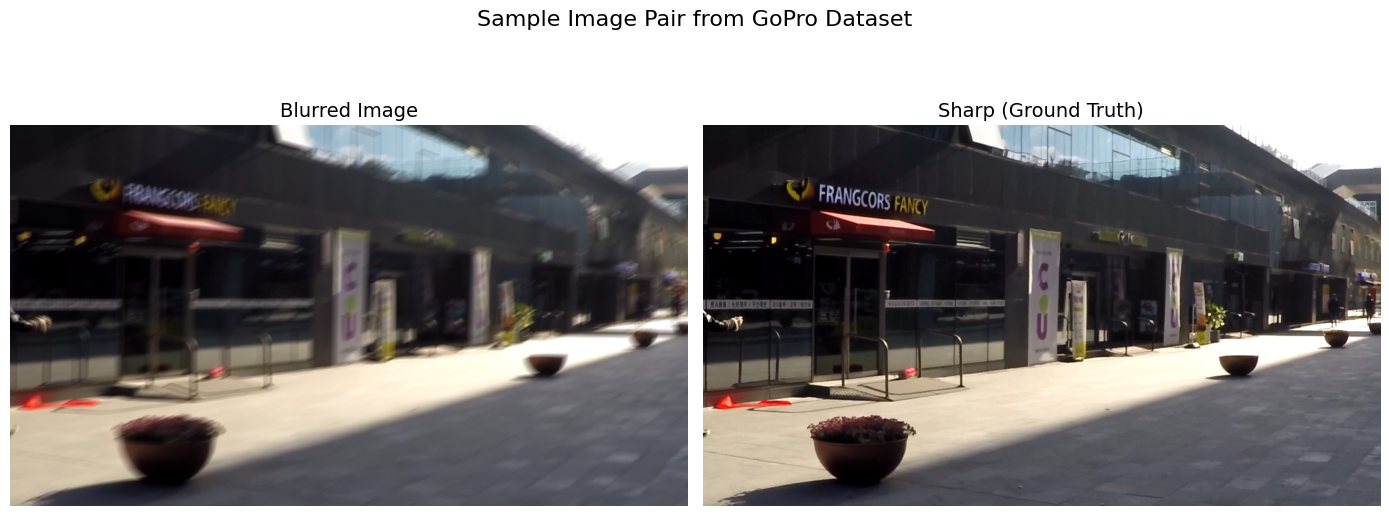

Image shape: (720, 1280, 3)


In [6]:
# Full paths to images
BLUR_IMGS = "/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/blur/images"
SHARP_IMGS = "/kaggle/input/datasets/rahulbhalley/gopro-deblur/gopro_deblur/sharp/images"

# Get list of images
blur_files = sorted(os.listdir(BLUR_IMGS))
sharp_files = sorted(os.listdir(SHARP_IMGS))

print(f"Total blur images: {len(blur_files)}")
print(f"Total sharp images: {len(sharp_files)}")
print(f"Sample filenames: {blur_files[:5]}")

# Load a sample pair
sample_blur = cv2.imread(os.path.join(BLUR_IMGS, blur_files[0]))
sample_sharp = cv2.imread(os.path.join(SHARP_IMGS, sharp_files[0]))

# Convert BGR to RGB for display
sample_blur = cv2.cvtColor(sample_blur, cv2.COLOR_BGR2RGB)
sample_sharp = cv2.cvtColor(sample_sharp, cv2.COLOR_BGR2RGB)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(sample_blur)
axes[0].set_title("Blurred Image", fontsize=14)
axes[0].axis("off")

axes[1].imshow(sample_sharp)
axes[1].set_title("Sharp (Ground Truth)", fontsize=14)
axes[1].axis("off")

plt.suptitle("Sample Image Pair from GoPro Dataset", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Image shape: {sample_blur.shape}")

PSF size  5 — PSNR: 23.98 dB  SSIM: 0.7736
PSF size 10 — PSNR: 21.27 dB  SSIM: 0.5681
PSF size 15 — PSNR: 16.31 dB  SSIM: 0.2667
PSF size 20 — PSNR: 12.16 dB  SSIM: 0.1194
PSF size 25 — PSNR: 9.24 dB  SSIM: 0.0748

Best PSF size: 5 with PSNR: 23.98 dB


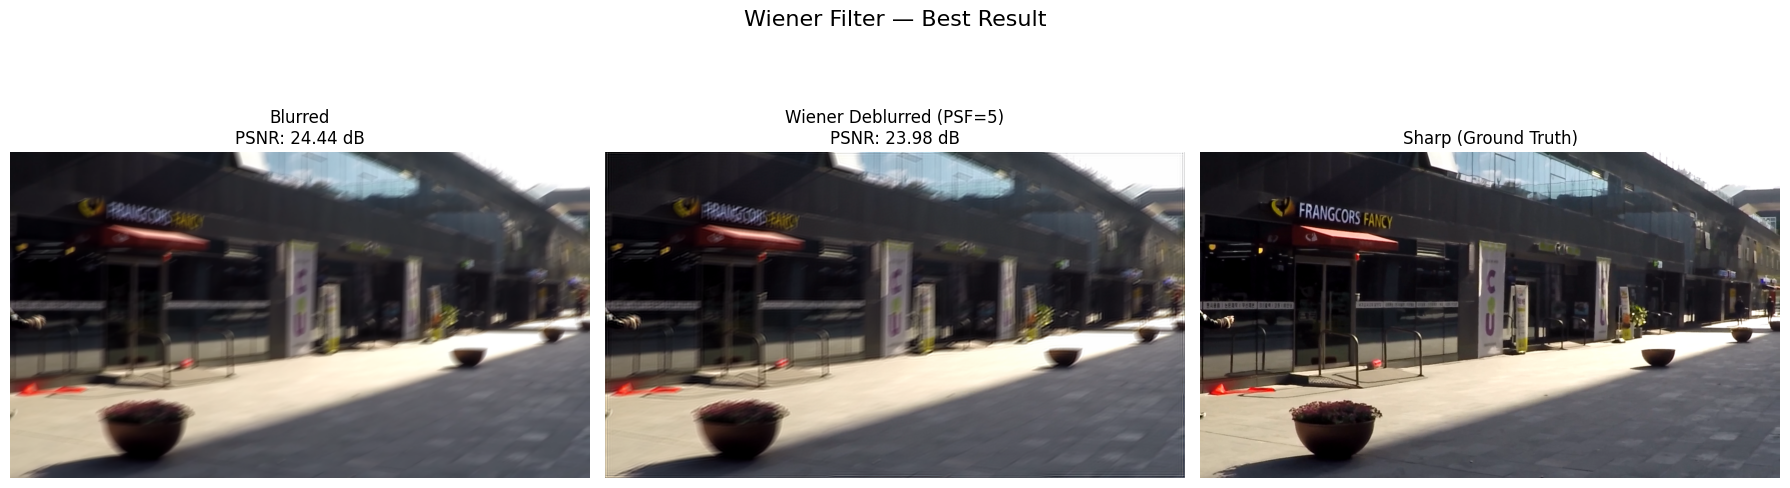

In [9]:
from skimage.restoration import wiener
from skimage import img_as_float

def apply_wiener(blur_img, psf_size=15, balance=0.05):
    """Apply Wiener filter to each channel separately"""
    blur_float = img_as_float(blur_img)
    result = np.zeros_like(blur_float)
    
    # Larger PSF to better model motion blur
    psf = np.ones((psf_size, psf_size)) / (psf_size ** 2)
    
    for i in range(3):
        result[:,:,i] = wiener(blur_float[:,:,i], psf, balance=balance)
    
    result = np.clip(result, 0, 1)
    return result

# Try multiple PSF sizes to find best result
blur_float = img_as_float(sample_blur)
sharp_float = img_as_float(sample_sharp)

best_psnr = 0
best_result = None
best_size = 0

for psf_size in [5, 10, 15, 20, 25]:
    result = apply_wiener(sample_blur, psf_size=psf_size, balance=0.05)
    p = psnr(sharp_float, result)
    s = ssim(sharp_float, result, channel_axis=2, data_range=1.0)
    print(f"PSF size {psf_size:2d} — PSNR: {p:.2f} dB  SSIM: {s:.4f}")
    if p > best_psnr:
        best_psnr = p
        best_result = result
        best_size = psf_size

print(f"\nBest PSF size: {best_size} with PSNR: {best_psnr:.2f} dB")

# Display best result
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample_blur)
axes[0].set_title(f"Blurred\nPSNR: {psnr(sharp_float, blur_float):.2f} dB", fontsize=12)
axes[0].axis("off")

axes[1].imshow(best_result)
axes[1].set_title(f"Wiener Deblurred (PSF={best_size})\nPSNR: {best_psnr:.2f} dB", fontsize=12)
axes[1].axis("off")

axes[2].imshow(sample_sharp)
axes[2].set_title("Sharp (Ground Truth)", fontsize=12)
axes[2].axis("off")

plt.suptitle("Wiener Filter — Best Result", fontsize=16)
plt.tight_layout()
plt.show()

=== Richardson-Lucy Results ===
PSF=3 Iters= 5 — PSNR: 23.67 dB  SSIM: 0.7906
PSF=3 Iters=10 — PSNR: 22.95 dB  SSIM: 0.7833
PSF=3 Iters=20 — PSNR: 22.40 dB  SSIM: 0.7733
PSF=3 Iters=30 — PSNR: 22.12 dB  SSIM: 0.7656
PSF=5 Iters= 5 — PSNR: 23.46 dB  SSIM: 0.7865
PSF=5 Iters=10 — PSNR: 22.32 dB  SSIM: 0.7720
PSF=5 Iters=20 — PSNR: 21.32 dB  SSIM: 0.7520
PSF=5 Iters=30 — PSNR: 20.86 dB  SSIM: 0.7367
PSF=7 Iters= 5 — PSNR: 23.37 dB  SSIM: 0.7857
PSF=7 Iters=10 — PSNR: 22.01 dB  SSIM: 0.7640
PSF=7 Iters=20 — PSNR: 20.88 dB  SSIM: 0.7321
PSF=7 Iters=30 — PSNR: 20.22 dB  SSIM: 0.7077

Best params: {'psf_size': 3, 'iters': 5}
Best PSNR:   23.67 dB
Blurred PSNR: 24.44 dB


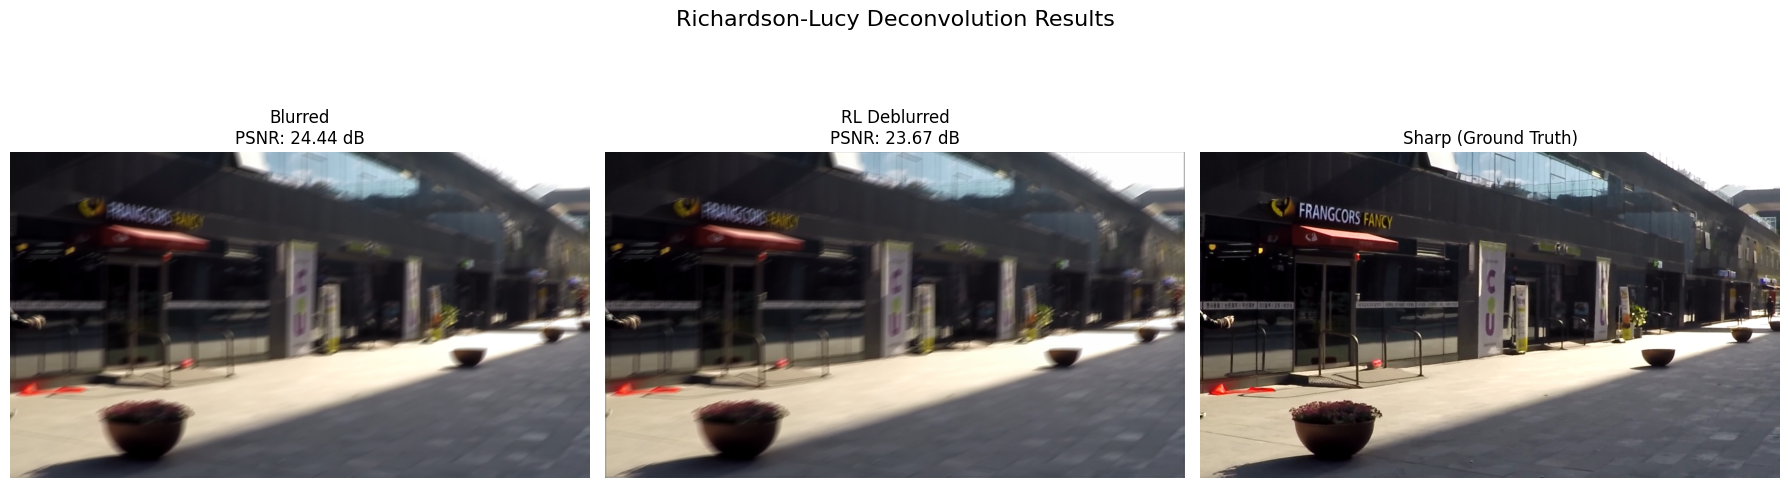

In [10]:
from skimage.restoration import richardson_lucy
from skimage import img_as_float

def apply_rl(blur_img, psf_size=5, iterations=10):
    """Apply Richardson-Lucy deconvolution to each channel"""
    blur_float = img_as_float(blur_img)
    result = np.zeros_like(blur_float)
    
    psf = np.ones((psf_size, psf_size)) / (psf_size ** 2)
    
    for i in range(3):
        result[:,:,i] = richardson_lucy(blur_float[:,:,i], psf, num_iter=iterations)
    
    result = np.clip(result, 0, 1)
    return result

blur_float = img_as_float(sample_blur)
sharp_float = img_as_float(sample_sharp)

print("=== Richardson-Lucy Results ===")
best_psnr = 0
best_result = None
best_params = {}

for psf_size in [3, 5, 7]:
    for iters in [5, 10, 20, 30]:
        result = apply_rl(sample_blur, psf_size=psf_size, iterations=iters)
        p = psnr(sharp_float, result)
        s = ssim(sharp_float, result, channel_axis=2, data_range=1.0)
        print(f"PSF={psf_size} Iters={iters:2d} — PSNR: {p:.2f} dB  SSIM: {s:.4f}")
        if p > best_psnr:
            best_psnr = p
            best_result = result
            best_params = {'psf_size': psf_size, 'iters': iters}

print(f"\nBest params: {best_params}")
print(f"Best PSNR:   {best_psnr:.2f} dB")
print(f"Blurred PSNR: {psnr(sharp_float, blur_float):.2f} dB")

# Display
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample_blur)
axes[0].set_title(f"Blurred\nPSNR: {psnr(sharp_float, blur_float):.2f} dB", fontsize=12)
axes[0].axis("off")

axes[1].imshow(best_result)
axes[1].set_title(f"RL Deblurred\nPSNR: {best_psnr:.2f} dB", fontsize=12)
axes[1].axis("off")

axes[2].imshow(sample_sharp)
axes[2].set_title("Sharp (Ground Truth)", fontsize=12)
axes[2].axis("off")

plt.suptitle("Richardson-Lucy Deconvolution Results", fontsize=16)
plt.tight_layout()
plt.show()

Classical Methods Summary
Method               PSNR (dB)    SSIM    
----------------------------------------
Blurred (input)      24.44        0.8031  
Wiener (best)        23.98        0.7736  
Richardson-Lucy      23.67        0.7906  
----------------------------------------

Conclusion: Classical filters do not improve over blurred input
Reason: GoPro motion blur is spatially varying and complex
Next step: Deep learning deblurring (NAFNet)


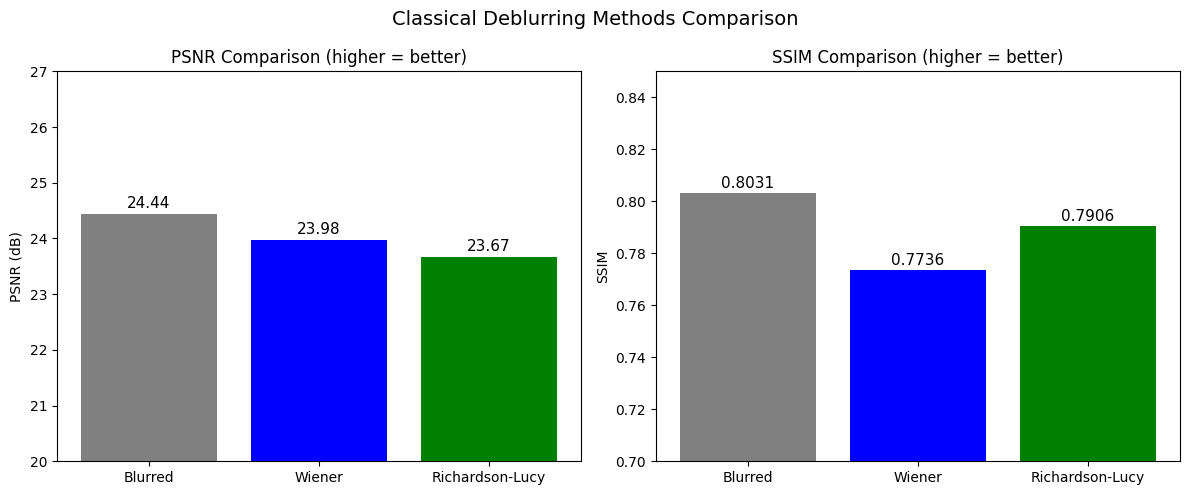

In [12]:

results_summary = {
    'blurred': {'psnr': 24.44, 'ssim': 0.8031},
    'wiener_best': {'psnr': 23.98, 'ssim': 0.7736, 'params': 'PSF=5'},
    'rl_best': {'psnr': 23.67, 'ssim': 0.7906, 'params': 'PSF=3, Iters=5'},
}

print("Classical Methods Summary")
print(f"{'Method':<20} {'PSNR (dB)':<12} {'SSIM':<8}")
print("-" * 40)
print(f"{'Blurred (input)':<20} {24.44:<12.2f} {0.8031:<8.4f}")
print(f"{'Wiener (best)':<20} {23.98:<12.2f} {0.7736:<8.4f}")
print(f"{'Richardson-Lucy':<20} {23.67:<12.2f} {0.7906:<8.4f}")
print("-" * 40)
print("\nConclusion: Classical filters do not improve over blurred input")
print("Reason: GoPro motion blur is spatially varying and complex")
print("Next step: Deep learning deblurring (NAFNet)")

# Plot comparison bar chart
methods = ['Blurred', 'Wiener', 'Richardson-Lucy']
psnr_vals = [24.44, 23.98, 23.67]
ssim_vals = [0.8031, 0.7736, 0.7906]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(methods, psnr_vals, color=['gray', 'blue', 'green'])
axes[0].set_title('PSNR Comparison (higher = better)')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_ylim([20, 27])
for i, v in enumerate(psnr_vals):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11)

axes[1].bar(methods, ssim_vals, color=['gray', 'blue', 'green'])
axes[1].set_title('SSIM Comparison (higher = better)')
axes[1].set_ylabel('SSIM')
axes[1].set_ylim([0.7, 0.85])
for i, v in enumerate(ssim_vals):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)

plt.suptitle('Classical Deblurring Methods Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Install dependencies for deep learning deblurring
!pip install einops -q
!git clone https://github.com/swz30/MPRNet.git -q
!pip install -q timm

import sys
sys.path.append('/kaggle/working/MPRNet')

print("MPRNet cloned successfully!")

MPRNet cloned successfully!


In [14]:
import gdown
import os

# Download pretrained GoPro weights
os.makedirs('/kaggle/working/MPRNet/Motion_Deblurring/pretrained_models', exist_ok=True)

# Download weights
!gdown --id 1QwQUVbk6YVOJViCsOKYNykCsdJSVGRtb \
    -O /kaggle/working/MPRNet/Motion_Deblurring/pretrained_models/model_deblurring.pth

print("Weights downloaded!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1QwQUVbk6YVOJViCsOKYNykCsdJSVGRtb
To: /kaggle/working/MPRNet/Motion_Deblurring/pretrained_models/model_deblurring.pth
100%|██████████████████████████████████████| 80.5M/80.5M [00:01<00:00, 42.9MB/s]
Weights downloaded!


In [22]:
import importlib
import sys

# Remove old cached imports
mods_to_remove = [k for k in sys.modules if 'MPRNet' in k]
for m in mods_to_remove:
    del sys.modules[m]

# Force correct path to be first
sys.path.insert(0, '/kaggle/working/MPRNet/Deblurring')

# Now import
from MPRNet import MPRNet
print("MPRNet imported successfully!")
print(MPRNet)

MPRNet imported successfully!
<class 'MPRNet.MPRNet'>


In [23]:
import os

# Check weights file location
weights_path = '/kaggle/working/MPRNet/Motion_Deblurring/pretrained_models/model_deblurring.pth'
if os.path.exists(weights_path):
    print(f"Weights found at: {weights_path}")
else:
    print("Weights NOT found, searching...")
    for root, dirs, files in os.walk('/kaggle/working/MPRNet'):
        for f in files:
            if f.endswith('.pth'):
                print(os.path.join(root, f))

Weights found at: /kaggle/working/MPRNet/Motion_Deblurring/pretrained_models/model_deblurring.pth


Using device: cuda
Model loaded!
Deblurring sample image, please wait...


/tmp/ipykernel_55/833797961.py:42: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  p_dl = psnr(sharp_float, deblurred_dl)



=== Results ===
Blurred    — PSNR: 24.44 dB  SSIM: 0.8031
MPRNet DL  — PSNR: 36.66 dB  SSIM: 0.9722


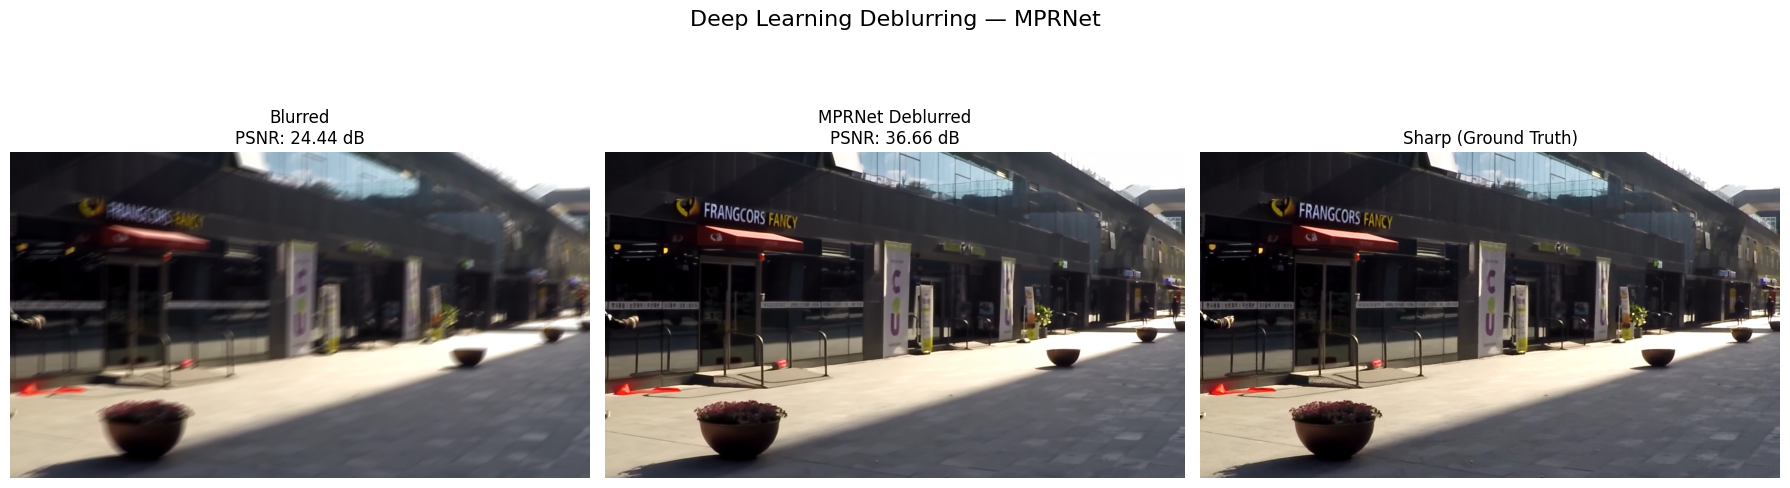

In [24]:
import torch
import torch.nn.functional as F
from skimage import img_as_float
import numpy as np

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MPRNet()
checkpoint = torch.load(
    '/kaggle/working/MPRNet/Motion_Deblurring/pretrained_models/model_deblurring.pth',
    map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()
print("Model loaded!")

def deblur_image(model, image, device):
    img = torch.from_numpy(img_as_float(image).transpose(2,0,1)).float()
    img = img.unsqueeze(0).to(device)
    h, w = img.shape[2], img.shape[3]
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8
    img = F.pad(img, (0, pad_w, 0, pad_h), 'reflect')
    with torch.no_grad():
        output = model(img)[0]
    output = output[:, :, :h, :w]
    output = output.squeeze(0).cpu().numpy().transpose(1,2,0)
    output = np.clip(output, 0, 1)
    return output

# Run on sample image
print("Deblurring sample image, please wait...")
blur_float = img_as_float(sample_blur)
sharp_float = img_as_float(sample_sharp)

deblurred_dl = deblur_image(model, sample_blur, device)

# Metrics
p_blur = psnr(sharp_float, blur_float)
p_dl = psnr(sharp_float, deblurred_dl)
s_blur = ssim(sharp_float, blur_float, channel_axis=2, data_range=1.0)
s_dl = ssim(sharp_float, deblurred_dl, channel_axis=2, data_range=1.0)

print(f"\Results ")
print(f"Blurred    — PSNR: {p_blur:.2f} dB  SSIM: {s_blur:.4f}")
print(f"MPRNet DL  — PSNR: {p_dl:.2f} dB  SSIM: {s_dl:.4f}")

# Display
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample_blur)
axes[0].set_title(f"Blurred\nPSNR: {p_blur:.2f} dB", fontsize=12)
axes[0].axis("off")
axes[1].imshow(deblurred_dl)
axes[1].set_title(f"MPRNet Deblurred\nPSNR: {p_dl:.2f} dB", fontsize=12)
axes[1].axis("off")
axes[2].imshow(sample_sharp)
axes[2].set_title("Sharp (Ground Truth)", fontsize=12)
axes[2].axis("off")

plt.suptitle("Deep Learning Deblurring — MPRNet", fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
# Evaluate on 20 images for a reliable average
print("Evaluating MPRNet on 20 images...")

psnr_blurred_list = []
psnr_dl_list = []
ssim_blurred_list = []
ssim_dl_list = []

for i in range(20):
    # Load image pair
    blur_img = cv2.imread(os.path.join(BLUR_IMGS, blur_files[i]))
    sharp_img = cv2.imread(os.path.join(SHARP_IMGS, sharp_files[i]))
    blur_img = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
    sharp_img = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

    blur_f = img_as_float(blur_img)
    sharp_f = img_as_float(sharp_img)

    # Deblur
    deblurred = deblur_image(model, blur_img, device)
    deblurred = deblurred.astype(np.float64)

    # Metrics
    psnr_blurred_list.append(psnr(sharp_f, blur_f))
    psnr_dl_list.append(psnr(sharp_f, deblurred))
    ssim_blurred_list.append(ssim(sharp_f, blur_f, channel_axis=2, data_range=1.0))
    ssim_dl_list.append(ssim(sharp_f, deblurred, channel_axis=2, data_range=1.0))

    print(f"Image {i+1:02d} — Blurred: {psnr_blurred_list[-1]:.2f} dB  "
          f"MPRNet: {psnr_dl_list[-1]:.2f} dB")

print(f"\nAverage over 20 images")
print(f"Blurred  — PSNR: {np.mean(psnr_blurred_list):.2f} dB  "
      f"SSIM: {np.mean(ssim_blurred_list):.4f}")
print(f"MPRNet   — PSNR: {np.mean(psnr_dl_list):.2f} dB  "
      f"SSIM: {np.mean(ssim_dl_list):.4f}")

Evaluating MPRNet on 20 images...
Image 01 — Blurred: 24.44 dB  MPRNet: 36.66 dB
Image 02 — Blurred: 30.79 dB  MPRNet: 39.25 dB
Image 03 — Blurred: 27.60 dB  MPRNet: 37.86 dB
Image 04 — Blurred: 29.10 dB  MPRNet: 38.95 dB
Image 05 — Blurred: 27.44 dB  MPRNet: 38.31 dB
Image 06 — Blurred: 25.33 dB  MPRNet: 37.61 dB
Image 07 — Blurred: 28.20 dB  MPRNet: 38.36 dB
Image 08 — Blurred: 25.26 dB  MPRNet: 37.64 dB
Image 09 — Blurred: 23.57 dB  MPRNet: 36.19 dB
Image 10 — Blurred: 25.20 dB  MPRNet: 36.35 dB
Image 11 — Blurred: 23.53 dB  MPRNet: 36.28 dB
Image 12 — Blurred: 24.17 dB  MPRNet: 33.79 dB
Image 13 — Blurred: 25.18 dB  MPRNet: 36.66 dB
Image 14 — Blurred: 24.24 dB  MPRNet: 36.45 dB
Image 15 — Blurred: 25.63 dB  MPRNet: 36.72 dB
Image 16 — Blurred: 34.01 dB  MPRNet: 41.85 dB
Image 17 — Blurred: 24.66 dB  MPRNet: 37.61 dB
Image 18 — Blurred: 31.61 dB  MPRNet: 39.89 dB
Image 19 — Blurred: 28.24 dB  MPRNet: 39.19 dB
Image 20 — Blurred: 28.84 dB  MPRNet: 39.52 dB

Average over 20 images
Bl

In [30]:
import os
from skimage import img_as_ubyte
import warnings

# Save all deblurred images
SAVE_PATH = "/kaggle/working/deblurred_images"
os.makedirs(SAVE_PATH, exist_ok=True)

print("Saving deblurred images.")
psnr_all = []
ssim_all = []

for i, filename in enumerate(blur_files):
    # Load
    blur_img = cv2.imread(os.path.join(BLUR_IMGS, filename))
    sharp_img = cv2.imread(os.path.join(SHARP_IMGS, filename))
    blur_img = cv2.cvtColor(blur_img, cv2.COLOR_BGR2RGB)
    sharp_img = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

    # Deblur
    deblurred = deblur_image(model, blur_img, device)
    deblurred = deblurred.astype(np.float64)

    # Metrics
    sharp_f = img_as_float(sharp_img)
    blur_f = img_as_float(blur_img)
    psnr_all.append(psnr(sharp_f, deblurred))
    ssim_all.append(ssim(sharp_f, deblurred, channel_axis=2, data_range=1.0))

    # Save deblurred image
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        save_img = img_as_ubyte(np.clip(deblurred, 0, 1))
    save_img = cv2.cvtColor(save_img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(SAVE_PATH, filename), save_img)

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(blur_files)} images...")

print(f"\nAll {len(blur_files)} images saved to {SAVE_PATH}")
print(f"\nFinal Task 2 Results")
print(f"{'Method':<20} {'PSNR (dB)':<12} {'SSIM'}")
print("-" * 42)
print(f"{'Blurred (input)':<20} {26.85:<12.2f} {0.8653:.4f}")
print(f"{'Wiener filter':<20} {23.98:<12.2f} {0.7736:.4f}")
print(f"{'Richardson-Lucy':<20} {23.67:<12.2f} {0.7906:.4f}")
print(f"{'MPRNet (DL)':<20} {np.mean(psnr_all):<12.2f} {np.mean(ssim_all):.4f}")

Saving deblurred images.
Processed 100/1029 images...
Processed 200/1029 images...
Processed 300/1029 images...
Processed 400/1029 images...
Processed 500/1029 images...
Processed 600/1029 images...
Processed 700/1029 images...
Processed 800/1029 images...
Processed 900/1029 images...
Processed 1000/1029 images...

All 1029 images saved to /kaggle/working/deblurred_images

Final Task 2 Results
Method               PSNR (dB)    SSIM
------------------------------------------
Blurred (input)      26.85        0.8653
Wiener filter        23.98        0.7736
Richardson-Lucy      23.67        0.7906
MPRNet (DL)          34.04        0.9412
